Importing Libraries

In [1]:
import matplotlib.pyplot as plt
import numpy as np
import PIL
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
from tensorflow.keras.models import Sequential

In [ ]:
#data_dir = r"C:\Users\HP\OneDrive\Desktop\ASD\ASD\AutismDataset\train"

In [2]:
# Set parameters
batch_size = 32
img_size = (224, 224)

In [ ]:
# Training dataset
train_ds = tf.keras.utils.image_dataset_from_directory(
    r"C:\Users\HP\OneDrive\Desktop\ASD\ASD\AutismDataset\train",
    seed=123,
    image_size=img_size,
    batch_size=batch_size
)

Found 2540 files belonging to 2 classes.


In [4]:
# Load the validation dataset
val_ds = tf.keras.utils.image_dataset_from_directory(
  r"C:\Users\HP\OneDrive\Desktop\ASD\ASD\AutismDataset\valid",
  seed=123,
  image_size=(img_size),
  batch_size=batch_size)

Found 100 files belonging to 2 classes.


In [5]:
class_names = train_ds.class_names
print(class_names)

['Autistic', 'Non_Autistic']


In [6]:
import json

with open("class_names.json", "w") as f:
    json.dump(class_names, f)


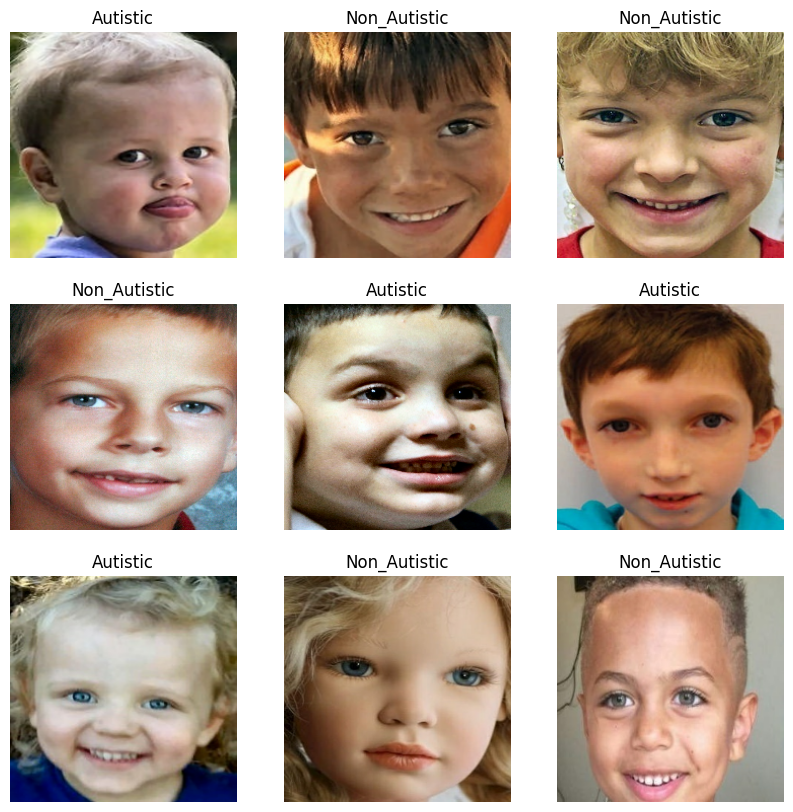

In [7]:
import matplotlib.pyplot as plt
# Visualize some training images
plt.figure(figsize=(10, 10))
for images, labels in train_ds.take(1):
  for i in range(9):
    ax = plt.subplot(3, 3, i + 1)
    plt.imshow(images[i].numpy().astype("uint8"))
    plt.title(class_names[labels[i]])
    plt.axis("off")

In [8]:
for image_batch, labels_batch in train_ds:
  print(image_batch.shape)
  print(labels_batch.shape)
  break

(32, 224, 224, 3)
(32,)


In [9]:
# Data Augmentation
data_augmentation = keras.Sequential(
  [
    layers.RandomFlip("horizontal",
                      input_shape=(224,
                                  224,
                                  3)),
    layers.RandomRotation(0.1),
    layers.RandomZoom(0.1),
  ]
)

C:\Users\HP\AppData\Roaming\Python\Python313\site-packages\keras\src\layers\preprocessing\tf_data_layer.py:19: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


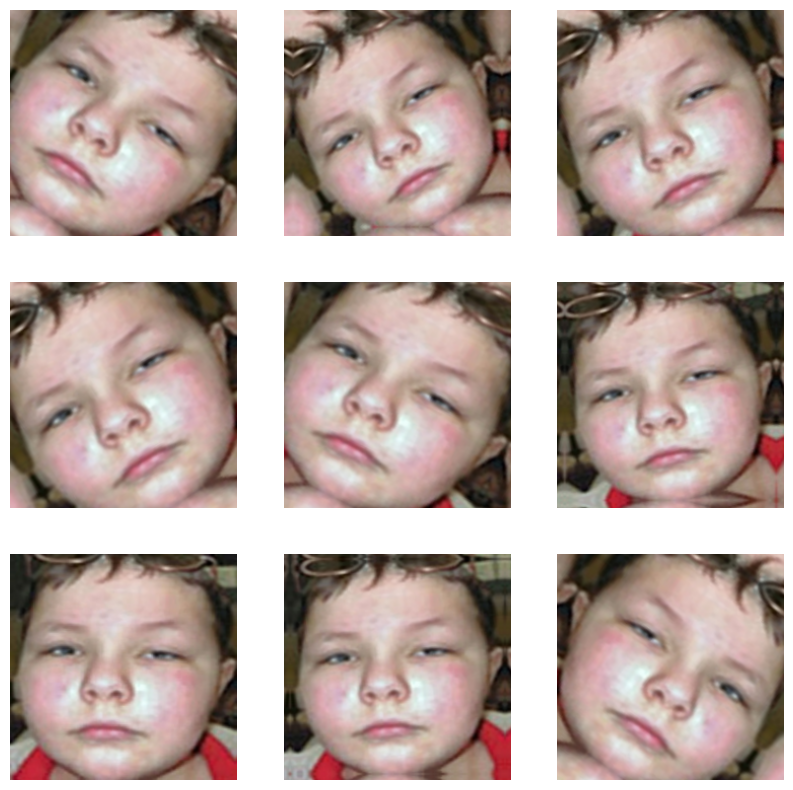

In [10]:
# Visualize some augmented images
plt.figure(figsize=(10, 10))
for images, _ in train_ds.take(1):
  for i in range(9):
    augmented_images = data_augmentation(images)
    ax = plt.subplot(3, 3, i + 1)
    plt.imshow(augmented_images[0].numpy().astype("uint8"))
    plt.axis("off")

Dataset Performance Optimization

In [11]:
# Configure the dataset for performance
AUTOTUNE = tf.data.AUTOTUNE

train_ds = train_ds.cache().shuffle(1000).prefetch(buffer_size=AUTOTUNE)
val_ds = val_ds.cache().prefetch(buffer_size=AUTOTUNE)

Simple CNN

In [24]:
num_classes = len(class_names)
# Build the model
model = Sequential([
  layers.Rescaling(1./255, input_shape=(224, 224, 3)),
  layers.Conv2D(16, 3, padding='same', activation='relu'),
  layers.MaxPooling2D(),
  layers.Conv2D(32, 3, padding='same', activation='relu'),
  layers.MaxPooling2D(),
  layers.Conv2D(64, 3, padding='same', activation='relu'),
  layers.MaxPooling2D(),
  layers.Flatten(),
  layers.Dense(128, activation='relu'),
  layers.Dense(num_classes)
])

In [25]:
# Compile the model
model.compile(optimizer='adam',
              loss=tf.keras.losses.SparseCategoricalCrossentropy(from_logits=True),
              metrics=['accuracy'])


In [26]:
model.summary() #Displays model architecture

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ rescaling_3 (Rescaling)         │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d (Conv2D)                 │ (None, 224, 224, 16)   │           448 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 112, 112, 16)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 112, 112, 32)   │         4,640 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 56, 56, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 56, 56, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 28, 28, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 50176)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_6 (Dense)                 │ (None, 128)            │     6,422,656 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_7 (Dense)                 │ (None, 2)              │           258 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 6,446,498 (24.59 MB)

 Trainable params: 6,446,498 (24.59 MB)

 Non-trainable params: 0 (0.00 B)

In [27]:
# Train the model
epochs=10
history = model.fit(
  train_ds,
  validation_data=val_ds,
  epochs=epochs
)

Epoch 1/10
80/80 ━━━━━━━━━━━━━━━━━━━━ 11s 130ms/step - accuracy: 0.6287 - loss: 0.7083 - val_accuracy: 0.6400 - val_loss: 0.6164
Epoch 2/10
80/80 ━━━━━━━━━━━━━━━━━━━━ 10s 128ms/step - accuracy: 0.7059 - loss: 0.5693 - val_accuracy: 0.7100 - val_loss: 0.5959
Epoch 3/10
80/80 ━━━━━━━━━━━━━━━━━━━━ 11s 133ms/step - accuracy: 0.7496 - loss: 0.5231 - val_accuracy: 0.7600 - val_loss: 0.5129
Epoch 4/10
80/80 ━━━━━━━━━━━━━━━━━━━━ 10s 131ms/step - accuracy: 0.7835 - loss: 0.4611 - val_accuracy: 0.7300 - val_loss: 0.5084
Epoch 5/10
80/80 ━━━━━━━━━━━━━━━━━━━━ 11s 133ms/step - accuracy: 0.8236 - loss: 0.4058 - val_accuracy: 0.7700 - val_loss: 0.5223
Epoch 6/10
80/80 ━━━━━━━━━━━━━━━━━━━━ 11s 136ms/step - accuracy: 0.8606 - loss: 0.3250 - val_accuracy: 0.7700 - val_loss: 0.6013
Epoch 7/10
80/80 ━━━━━━━━━━━━━━━━━━━━ 11s 135ms/step - accuracy: 0.9091 - loss: 0.2284 - val_accuracy: 0.8100 - val_loss: 0.6265
Epoch 8/10
80/80 ━━━━━━━━━━━━━━━━━━━━ 11s 135ms/step - accuracy: 0.9417 - loss: 0.1616 - val_accu

In [17]:
from tensorflow.keras.models import Model

In [18]:
# Create a new model that outputs the features from the Dense(128) layer
feature_extractor = Model(
    inputs=model.inputs,
    outputs=model.layers[-2].output   # Dense(128) layer
)

In [19]:
# Extract features for the training dataset
train_features = feature_extractor.predict(train_ds)


80/80 ━━━━━━━━━━━━━━━━━━━━ 4s 47ms/step


In [20]:
import pandas as pd

feature_names = [f"feature_{i+1}" for i in range(train_features.shape[1])]

In [21]:
df_features = pd.DataFrame(train_features, columns=feature_names)

In [22]:
df_features.to_csv("cnn_extracted_features.csv", index=False)

In [22]:
print(train_features[0])   # features of first image

[ 0.          2.0409956   0.          0.          0.          4.1288447
  0.          0.19977055  0.          0.          0.          0.
  0.          0.          0.          0.          0.          0.
  0.          0.          0.15118425  0.6102707   0.          0.
  0.          0.          0.          1.1614394   0.          0.
  0.          4.853085    0.          0.          0.          0.
  3.8990564   6.5518456   0.          0.          0.          0.41659027
  0.          0.          0.          0.          0.          0.
  0.          0.          0.          3.3447094   0.          0.
  0.          0.          0.          0.          0.          0.
  0.          0.          0.17346889  1.8273247   3.7967937   0.
  0.67685723 10.281906    0.          3.5576344   0.          0.
  0.          0.          6.6012435   0.          0.          0.
  0.          0.          0.          6.1890283   0.          0.
  0.          0.          5.9820256   0.          0.          0.
  0.      

In [14]:
# Save the model
model.save("asd_cnn_model1.keras")

In [22]:
model.save("asd_cnn_model.h5")  # HDF5 format


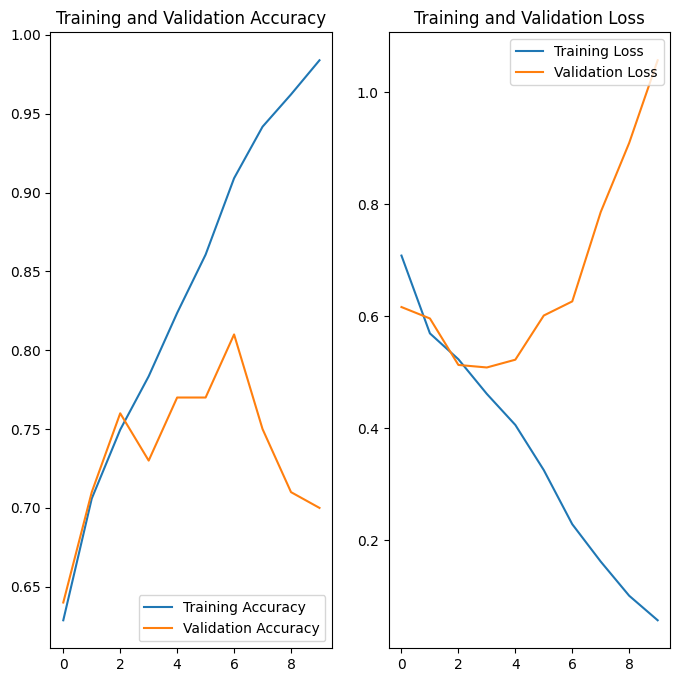

In [28]:
acc = history.history['accuracy']
val_acc = history.history['val_accuracy']

loss = history.history['loss']
val_loss = history.history['val_loss']

epochs_range = range(epochs)

plt.figure(figsize=(8, 8))
plt.subplot(1, 2, 1)
plt.plot(epochs_range, acc, label='Training Accuracy')
plt.plot(epochs_range, val_acc, label='Validation Accuracy')
plt.legend(loc='lower right')
plt.title('Training and Validation Accuracy')

plt.subplot(1, 2, 2)
plt.plot(epochs_range, loss, label='Training Loss')
plt.plot(epochs_range, val_loss, label='Validation Loss')
plt.legend(loc='upper right')
plt.title('Training and Validation Loss')
plt.show()

MobileNetV2

In [12]:
import tensorflow as tf
from tensorflow.keras import layers, Model
from tensorflow.keras.applications import MobileNetV2

num_classes = len(class_names)  # Number of classes in your dataset
input_shape = (224, 224, 3)    # Adjust according to your images

# Load MobileNetV2 without top layers and with pre-trained weights
base_model = MobileNetV2(input_shape=input_shape,
                         include_top=False,
                         weights='imagenet')

# Freeze the base model so we don't train pre-trained weights
base_model.trainable = False

# Add custom classification head
inputs = tf.keras.Input(shape=input_shape)
x = layers.Rescaling(1./255)(inputs)  # normalize input
x = base_model(x, training=False)      # pass through MobileNetV2
x = layers.GlobalAveragePooling2D()(x)
x = layers.Dense(128, activation='relu')(x)
outputs = layers.Dense(num_classes)(x)  # logits, not softmax
model_mobilenet = Model(inputs, outputs)

# Compile the model
model_mobilenet.compile(optimizer='adam',
              loss=tf.keras.losses.SparseCategoricalCrossentropy(from_logits=True),
              metrics=['accuracy'])

model_mobilenet.summary()


Model: "functional_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_2 (InputLayer)      │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ rescaling (Rescaling)           │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ mobilenetv2_1.00_224            │ (None, 7, 7, 1280)     │     2,257,984 │
│ (Functional)                    │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 1280)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │       163,968 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 2)              │           258 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,422,210 (9.24 MB)

 Trainable params: 164,226 (641.51 KB)

 Non-trainable params: 2,257,984 (8.61 MB)

In [13]:
epochs = 10
history_mobilenet = model_mobilenet.fit(
    train_ds,
    validation_data=val_ds,
    epochs=epochs
)

Epoch 1/10
80/80 ━━━━━━━━━━━━━━━━━━━━ 47s 483ms/step - accuracy: 0.7059 - loss: 0.5785 - val_accuracy: 0.7300 - val_loss: 0.5528
Epoch 2/10
80/80 ━━━━━━━━━━━━━━━━━━━━ 47s 584ms/step - accuracy: 0.7929 - loss: 0.4337 - val_accuracy: 0.7500 - val_loss: 0.5428
Epoch 3/10
80/80 ━━━━━━━━━━━━━━━━━━━━ 25s 318ms/step - accuracy: 0.8280 - loss: 0.3923 - val_accuracy: 0.7800 - val_loss: 0.5302
Epoch 4/10
80/80 ━━━━━━━━━━━━━━━━━━━━ 25s 307ms/step - accuracy: 0.8461 - loss: 0.3488 - val_accuracy: 0.7300 - val_loss: 0.5946
Epoch 5/10
80/80 ━━━━━━━━━━━━━━━━━━━━ 24s 301ms/step - accuracy: 0.8689 - loss: 0.3099 - val_accuracy: 0.7200 - val_loss: 0.5522
Epoch 6/10
80/80 ━━━━━━━━━━━━━━━━━━━━ 24s 305ms/step - accuracy: 0.8843 - loss: 0.2738 - val_accuracy: 0.7700 - val_loss: 0.5426
Epoch 7/10
80/80 ━━━━━━━━━━━━━━━━━━━━ 25s 308ms/step - accuracy: 0.8988 - loss: 0.2425 - val_accuracy: 0.7400 - val_loss: 0.5771
Epoch 8/10
80/80 ━━━━━━━━━━━━━━━━━━━━ 25s 308ms/step - accuracy: 0.9339 - loss: 0.1955 - val_accu

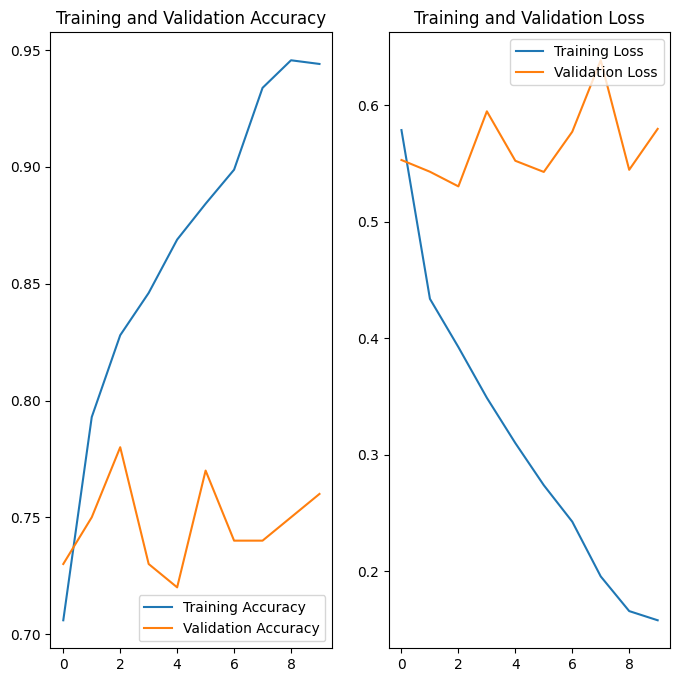

In [14]:
acc = history_mobilenet.history['accuracy']
val_acc = history_mobilenet.history['val_accuracy']

loss = history_mobilenet.history['loss']
val_loss = history_mobilenet.history['val_loss']

epochs_range = range(epochs)

plt.figure(figsize=(8, 8))
plt.subplot(1, 2, 1)
plt.plot(epochs_range, acc, label='Training Accuracy')
plt.plot(epochs_range, val_acc, label='Validation Accuracy')
plt.legend(loc='lower right')
plt.title('Training and Validation Accuracy')

plt.subplot(1, 2, 2)
plt.plot(epochs_range, loss, label='Training Loss')
plt.plot(epochs_range, val_loss, label='Validation Loss')
plt.legend(loc='upper right')
plt.title('Training and Validation Loss')
plt.show()

VGG16

In [15]:
import tensorflow as tf
from tensorflow.keras import layers, Model
from tensorflow.keras.applications import VGG16

num_classes = len(class_names)  # Number of classes in your dataset
input_shape = (224, 224, 3)    # Image size

# Load VGG16 without top layers
base_model = VGG16(input_shape=input_shape,
                   include_top=False,
                   weights='imagenet')
base_model.trainable = False  # Freeze base model

# Add custom classification head
inputs = tf.keras.Input(shape=input_shape)
x = layers.Rescaling(1./255)(inputs)  # normalize input
x = base_model(x, training=False)
x = layers.GlobalAveragePooling2D()(x)
x = layers.Dense(128, activation='relu')(x)
outputs = layers.Dense(num_classes)(x)  # logits
model_vgg16 = Model(inputs, outputs)

# Compile the model
model_vgg16.compile(optimizer='adam',
              loss=tf.keras.losses.SparseCategoricalCrossentropy(from_logits=True),
              metrics=['accuracy'])

model_vgg16.summary()

Model: "functional_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_4 (InputLayer)      │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ rescaling_1 (Rescaling)         │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ vgg16 (Functional)              │ (None, 7, 7, 512)      │    14,714,688 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d_1      │ (None, 512)            │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 128)            │        65,664 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 2)              │           258 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 14,780,610 (56.38 MB)

 Trainable params: 65,922 (257.51 KB)

 Non-trainable params: 14,714,688 (56.13 MB)

In [16]:
# Train the model
epochs = 5
history_vgg16 = model_vgg16.fit(
    train_ds,
    validation_data=val_ds,
    epochs=epochs
)

Epoch 1/5
80/80 ━━━━━━━━━━━━━━━━━━━━ 346s 4s/step - accuracy: 0.6496 - loss: 0.6162 - val_accuracy: 0.6100 - val_loss: 0.6596
Epoch 2/5
80/80 ━━━━━━━━━━━━━━━━━━━━ 235s 3s/step - accuracy: 0.7240 - loss: 0.5462 - val_accuracy: 0.6600 - val_loss: 0.5516
Epoch 3/5
80/80 ━━━━━━━━━━━━━━━━━━━━ 224s 3s/step - accuracy: 0.7524 - loss: 0.5077 - val_accuracy: 0.7000 - val_loss: 0.5506
Epoch 4/5
80/80 ━━━━━━━━━━━━━━━━━━━━ 220s 3s/step - accuracy: 0.7630 - loss: 0.4862 - val_accuracy: 0.7100 - val_loss: 0.5315
Epoch 5/5
80/80 ━━━━━━━━━━━━━━━━━━━━ 245s 3s/step - accuracy: 0.7618 - loss: 0.4796 - val_accuracy: 0.7100 - val_loss: 0.5305


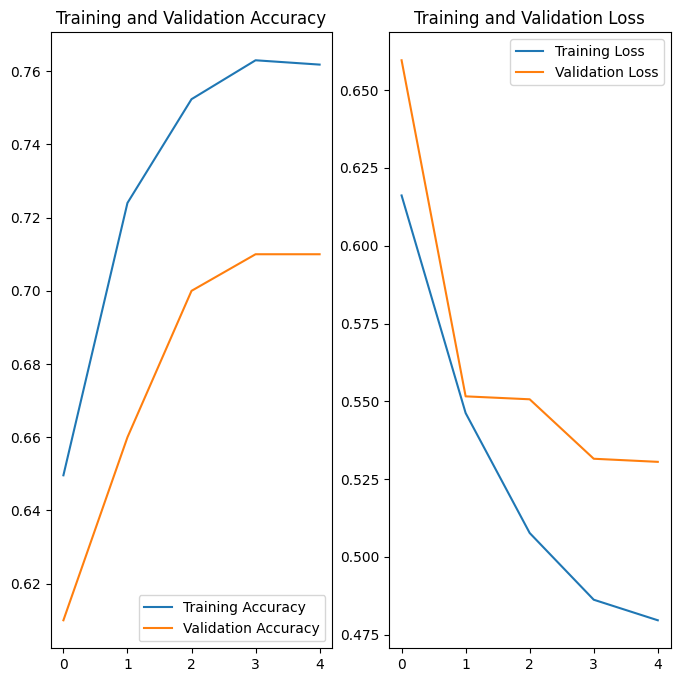

In [17]:
acc = history_vgg16.history['accuracy']
val_acc = history_vgg16.history['val_accuracy']

loss = history_vgg16.history['loss']
val_loss = history_vgg16.history['val_loss']

epochs_range = range(epochs)

plt.figure(figsize=(8, 8))
plt.subplot(1, 2, 1)
plt.plot(epochs_range, acc, label='Training Accuracy')
plt.plot(epochs_range, val_acc, label='Validation Accuracy')
plt.legend(loc='lower right')
plt.title('Training and Validation Accuracy')

plt.subplot(1, 2, 2)
plt.plot(epochs_range, loss, label='Training Loss')
plt.plot(epochs_range, val_loss, label='Validation Loss')
plt.legend(loc='upper right')
plt.title('Training and Validation Loss')
plt.show()

ResNet50

In [18]:
import tensorflow as tf
from tensorflow.keras import layers, Model
from tensorflow.keras.applications import ResNet50

num_classes = len(class_names)   # Number of classes in your dataset
input_shape = (224, 224, 3)      # Image size

# Load ResNet50 without the top layers
base_model = ResNet50(input_shape=input_shape,
                      include_top=False,
                      weights='imagenet')
base_model.trainable = False  # Freeze base model

# Add custom classification head
inputs = tf.keras.Input(shape=input_shape)
x = layers.Rescaling(1./255)(inputs)         # normalize pixels
x = base_model(x, training=False)            # pass through ResNet base
x = layers.GlobalAveragePooling2D()(x)       # reduce feature maps
x = layers.Dense(128, activation='relu')(x)  # fully connected layer
outputs = layers.Dense(num_classes)(x)       # logits (no softmax here)
model_resnet = Model(inputs, outputs)

In [19]:
model_resnet.compile(
    optimizer='adam',
    loss=tf.keras.losses.SparseCategoricalCrossentropy(from_logits=True),
    metrics=['accuracy']
)

In [20]:
model_resnet.summary()

Model: "functional_3"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_6 (InputLayer)      │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ rescaling_2 (Rescaling)         │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ resnet50 (Functional)           │ (None, 7, 7, 2048)     │    23,587,712 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d_2      │ (None, 2048)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 128)            │       262,272 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 2)              │           258 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 23,850,242 (90.98 MB)

 Trainable params: 262,530 (1.00 MB)

 Non-trainable params: 23,587,712 (89.98 MB)

In [21]:
epochs = 10
history_resnet = model_resnet.fit(
    train_ds,
    validation_data=val_ds,
    epochs=epochs
)

Epoch 1/10
80/80 ━━━━━━━━━━━━━━━━━━━━ 88s 1s/step - accuracy: 0.5319 - loss: 0.7069 - val_accuracy: 0.6600 - val_loss: 0.6508
Epoch 2/10
80/80 ━━━━━━━━━━━━━━━━━━━━ 82s 1s/step - accuracy: 0.5984 - loss: 0.6762 - val_accuracy: 0.6500 - val_loss: 0.6466
Epoch 3/10
80/80 ━━━━━━━━━━━━━━━━━━━━ 82s 1s/step - accuracy: 0.6098 - loss: 0.6692 - val_accuracy: 0.7100 - val_loss: 0.6264
Epoch 4/10
80/80 ━━━━━━━━━━━━━━━━━━━━ 83s 1s/step - accuracy: 0.6130 - loss: 0.6571 - val_accuracy: 0.6000 - val_loss: 0.6333
Epoch 5/10
80/80 ━━━━━━━━━━━━━━━━━━━━ 83s 1s/step - accuracy: 0.6102 - loss: 0.6556 - val_accuracy: 0.6600 - val_loss: 0.5999
Epoch 6/10
80/80 ━━━━━━━━━━━━━━━━━━━━ 84s 1s/step - accuracy: 0.6031 - loss: 0.6598 - val_accuracy: 0.7000 - val_loss: 0.6210
Epoch 7/10
80/80 ━━━━━━━━━━━━━━━━━━━━ 83s 1s/step - accuracy: 0.5972 - loss: 0.6633 - val_accuracy: 0.7300 - val_loss: 0.6054
Epoch 8/10
80/80 ━━━━━━━━━━━━━━━━━━━━ 83s 1s/step - accuracy: 0.6433 - loss: 0.6337 - val_accuracy: 0.6800 - val_loss:

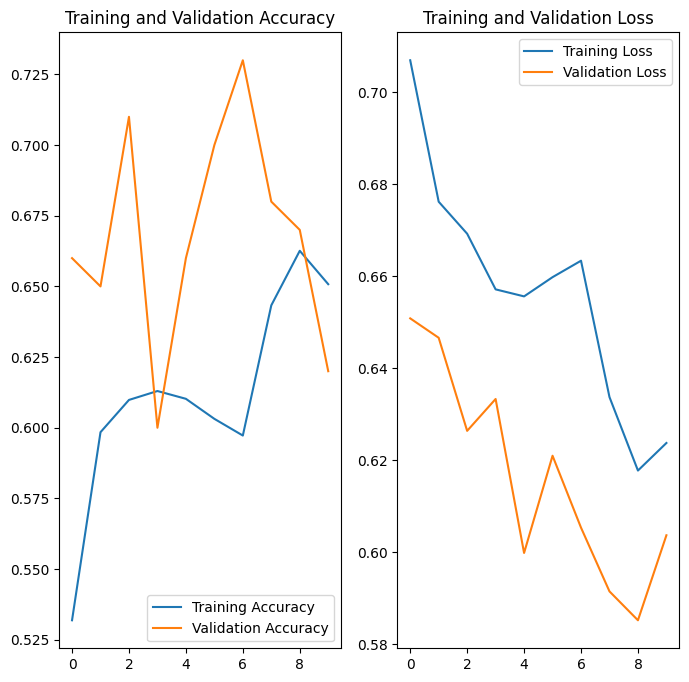

In [22]:
acc = history_resnet.history['accuracy']
val_acc = history_resnet.history['val_accuracy']

loss = history_resnet.history['loss']
val_loss = history_resnet.history['val_loss']

epochs_range = range(epochs)

plt.figure(figsize=(8, 8))
plt.subplot(1, 2, 1)
plt.plot(epochs_range, acc, label='Training Accuracy')
plt.plot(epochs_range, val_acc, label='Validation Accuracy')
plt.legend(loc='lower right')
plt.title('Training and Validation Accuracy')

plt.subplot(1, 2, 2)
plt.plot(epochs_range, loss, label='Training Loss')
plt.plot(epochs_range, val_loss, label='Validation Loss')
plt.legend(loc='upper right')
plt.title('Training and Validation Loss')
plt.show()

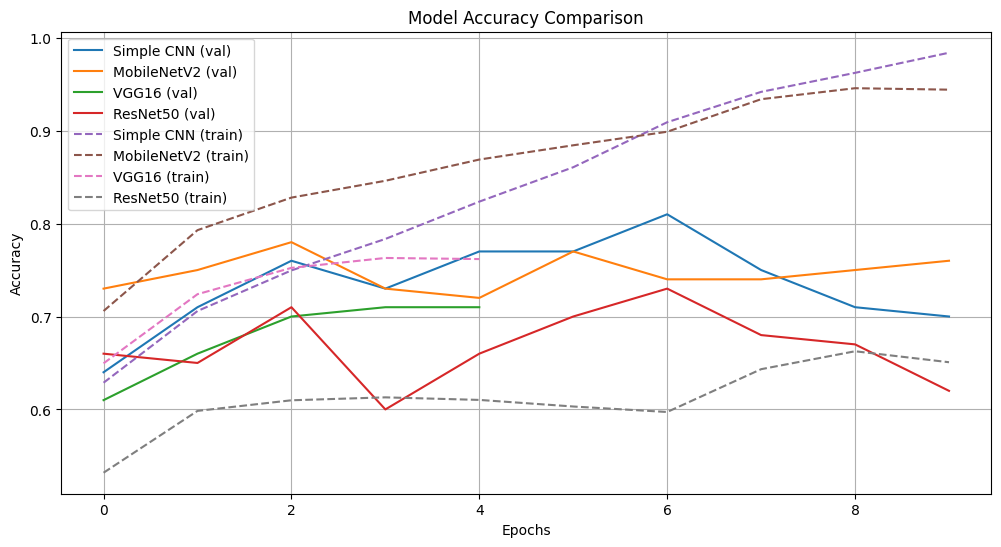

In [29]:
import matplotlib.pyplot as plt

# List of histories (change names to match your variables)
histories = {
    "Simple CNN": history,
    "MobileNetV2": history_mobilenet,
    "VGG16": history_vgg16,
    "ResNet50": history_resnet,
}

plt.figure(figsize=(12, 6))

# Plot validation accuracy for each model
for name, hist in histories.items():
    plt.plot(hist.history['val_accuracy'], label=f'{name} (val)')

# Optionally also plot training accuracy
for name, hist in histories.items():
    plt.plot(hist.history['accuracy'], linestyle="--", label=f'{name} (train)')

plt.title("Model Accuracy Comparison")
plt.xlabel("Epochs")
plt.ylabel("Accuracy")
plt.legend()
plt.grid(True)
plt.show()


In [5]:
import json

with open(r"C:\Users\HP\OneDrive\Desktop\ASD\ASD\class_names.json", "r") as f:
    class_names = json.load(f)

In [6]:
print("Model output shape:", model.output_shape)
print("Number of class names:", len(class_names))
print("Class names:", class_names)


Model output shape: (None, 2)
Number of class names: 2
Class names: ['Autistic', 'Non_Autistic']


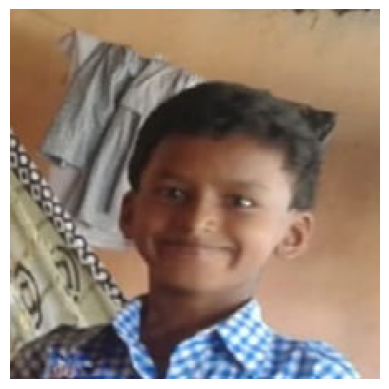

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 72ms/step
This image most likely belongs to Non_Autistic with a 99.94% confidence.


In [7]:
import tensorflow as tf
import numpy as np
import matplotlib.pyplot as plt

# Load the saved model
model = tf.keras.models.load_model(
    r"C:\Users\HP\OneDrive\Desktop\ASD\ASD\asd_cnn_model1.keras"
)

# Load and display image
img = tf.keras.utils.load_img(
    r"C:\Users\HP\OneDrive\Desktop\ASD\ASD\AutismDataset\Test4.jpg",
    target_size=(224, 224)
)

plt.imshow(img)
plt.axis('off')
plt.show()

# Convert image to array
img_array = tf.keras.utils.img_to_array(img)
img_array = tf.expand_dims(img_array, 0)  # batch of 1

# Predict
predictions = model.predict(img_array)

# Convert logits to probabilities
score = tf.nn.softmax(predictions[0])

# Display result
print(
    "This image most likely belongs to {} with a {:.2f}% confidence."
    .format(class_names[np.argmax(score)], 100 * np.max(score))
)
